# Notebook 02: Lake Tahoe Boundary Extraction

**Obstacle-Aware Clustering for Geographic Data**

In Notebook 01, we used a synthetic ellipse to demonstrate how the arc-length parameter $s$ corrects k-Means around an obstacle. Real-world obstacles like lakes don't have a clean parametric form, so we need a way to build a boundary representation directly from coordinate data. In this notebook, we extract the Lake Tahoe shoreline from the USGS National Hydrography Dataset, fit a cubic spline using our `SplineBoundary` class, and verify that arc-length calculation and point projection work correctly before moving on to the wildfire clustering analysis in Notebook 03.

---

## 1. Setup

In [3]:
import os
# Prevent sklearn/KMeans from spawning parallel threads on Windows
# (also suppresses a harmless OpenMP warning)
os.environ['OMP_NUM_THREADS'] = '1'

# Suppress scipy.integrate accuracy warnings that surface during
# arc-length calculations on the spline boundary
import warnings
warnings.filterwarnings('ignore', category=IntegrationWarning)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# For querying the NHD ArcGIS REST endpoint
import requests 

# For polygon clipping during boundary cleanup
from shapely.geometry import Polygon as ShapelyPolygon

# Our custom package
from obstacle_clustering import SplineBoundary

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 2. Querying the USGS National Hydrography Dataset

The [National Hydrography Dataset (NHD)](https://www.usgs.gov/national-hydrography/national-hydrography-dataset) is the USGS's authoritative database of U.S. surface water features -- lakes, rivers, streams, and reservoirs. NHD exposes this data through a public ArcGIS REST endpoint that accepts queries over HTTP and returns geometry in JSON format. We use Python's `requests` library to build the query URL, send it to the server, and parse the response.

**Data source**: USGS NHD Waterbody layer  
**Server**: `https://hydro.nationalmap.gov/arcgis/rest/services/nhd/MapServer/10`  
**Query field**: `GNIS_NAME` (Geographic Names Information System -- the federal standard for place names)

In [4]:
# USGS NHD Waterbody layer -- publicly accessible, no authentication required
NHD_WATERBODY_URL = (
    "https://hydro.nationalmap.gov/arcgis/rest/services/nhd/MapServer/10/query"
)

# Build the query parameters
params = {
    'where': "GNIS_NAME = 'Lake Tahoe'",   # SQL filter: find Lake Tahoe by name
    'outFields': 'GNIS_NAME,AREASQKM,ELEVATION,REACHCODE',  # attributes to return
    'returnGeometry': 'true',               # we want the polygon shape
    'outSR': 4326,                          # coordinate system: WGS 84 (lat/lon)
    'f': 'json',                            # response format: JSON
}

# Send the request to the USGS server
response = requests.get(NHD_WATERBODY_URL, params=params)
response.raise_for_status()  # raise an error if the request failed

data = response.json()

# Check what we got back
n_features = len(data['features'])
print(f'Features returned: {n_features}')

for feat in data['features']:
    attrs = feat['attributes']
    print(f"  Name:       {attrs['GNIS_NAME']}")
    print(f"  Area:       {attrs['AREASQKM']:.1f} sq km")
    print(f"  Elevation:  {attrs['ELEVATION']:.0f} m")
    print(f"  Reach Code: {attrs['REACHCODE']}")

Features returned: 6
  Name:       Lake Tahoe
  Area:       0.0 sq km
  Elevation:  0 m
  Reach Code: 02080203002790
  Name:       Lake Tahoe
  Area:       0.1 sq km
  Elevation:  0 m
  Reach Code: 03090206073133
  Name:       Lake Tahoe
  Area:       0.1 sq km
  Elevation:  0 m
  Reach Code: 03130005004183
  Name:       Lake Tahoe
  Area:       0.0 sq km
  Elevation:  0 m
  Reach Code: 06010105002593
  Name:       Lake Tahoe
  Area:       0.2 sq km
  Elevation:  0 m
  Reach Code: 07050002001323
  Name:       Lake Tahoe
  Area:       496.9 sq km
  Elevation:  1899 m
  Reach Code: 16050101000339


## 3. Extracting Boundary Coordinates

The query returned six features all named "Lake Tahoe," since GNIS allows duplicate place names across the country. We select the largest one by area (496.9 km²), which is the actual lake.

The geometry is stored as a polygon with rings -- arrays of `[longitude, latitude]` coordinate pairs that trace the shoreline. A polygon can have multiple rings (e.g., if it contains islands), so we take the longest ring as the main shoreline. We also confirm the ring is closed (the first and last points match), which is required for arc-length parameterization on a loop.

In [5]:
# The geometry is nested inside the feature's 'geometry' field
# Structure: feature -> geometry -> rings -> [[lon, lat], [lon, lat], ...]

# If multiple features were returned, pick the largest by area
if n_features > 1:
    feat = max(data['features'], key=lambda f: f['attributes']['AREASQKM'])
    print(f"Multiple features found — using the largest ({feat['attributes']['AREASQKM']:.1f} sq km)")
else:
    feat = data['features'][0]

rings = feat['geometry']['rings']
print(f'Number of rings: {len(rings)}')
for i, ring in enumerate(rings):
    print(f'  Ring {i}: {len(ring)} vertices')

# Use the longest ring as the exterior boundary
exterior_ring = max(rings, key=len)
coords = np.array(exterior_ring)

lon = coords[:, 0]  
lat = coords[:, 1]  

print(f'\nExterior ring: {len(lon)} vertices')
print(f'Longitude range: [{lon.min():.4f}, {lon.max():.4f}]')
print(f'Latitude range:  [{lat.min():.4f}, {lat.max():.4f}]')

# Verify the ring is closed
is_closed = np.allclose(coords[0], coords[-1])
print(f'Ring is closed: {is_closed}')

Multiple features found — using the largest (496.9 sq km)
Number of rings: 2
  Ring 0: 1528 vertices
  Ring 1: 11 vertices

Exterior ring: 1528 vertices
Longitude range: [-120.1635, -119.9262]
Latitude range:  [38.9286, 39.2489]
Ring is closed: True


### Visualizing the Raw Boundary ###

Before fitting splines, we plot the extracted coordinates to verify that the boundary looks correct. Lake Tahoe has a distinctive elongated shape running roughly north–south, about 35 km long and 19 km wide.

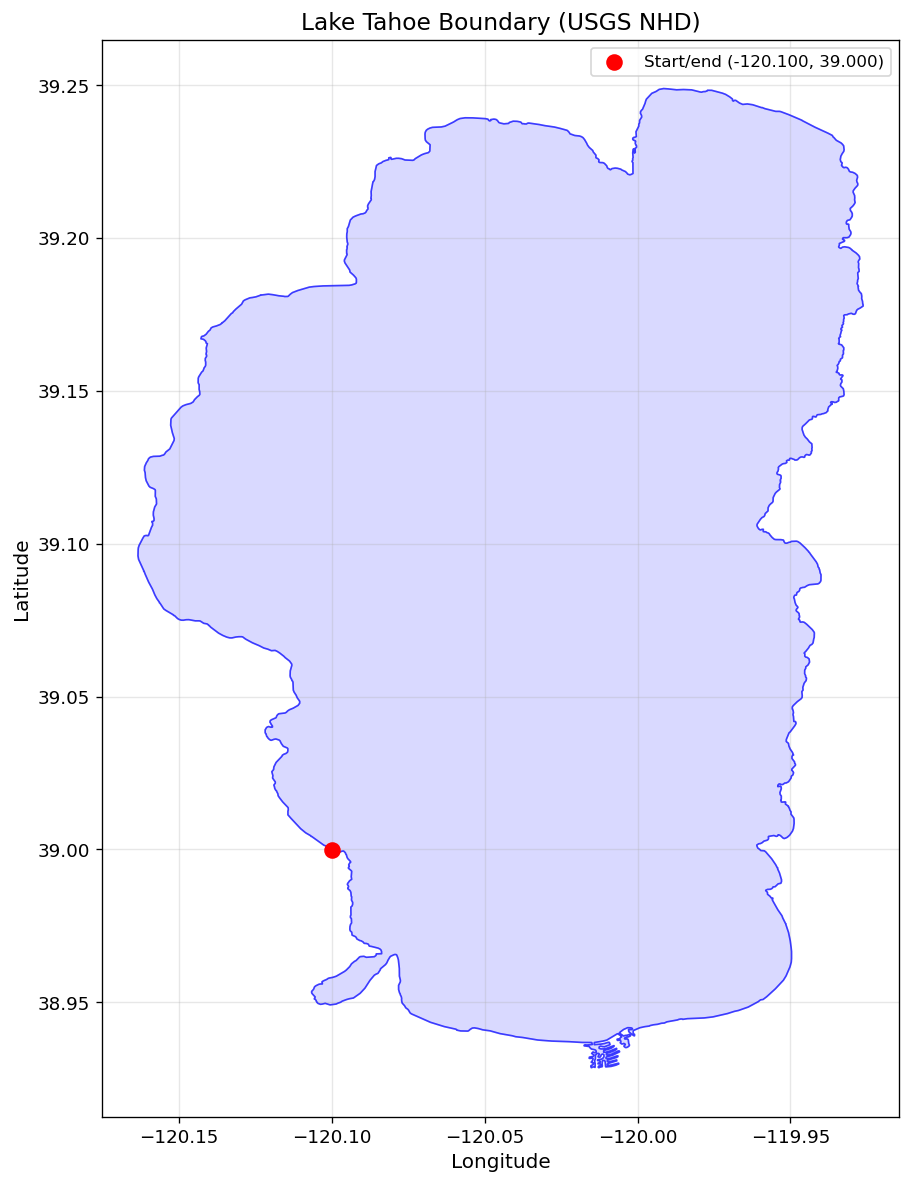

In [ ]:
# Plot the raw NHD boundary
fig, ax = plt.subplots(figsize=(8, 10))

ax.plot(lon, lat, 'b-', linewidth=1.0, alpha=0.7)
ax.fill(lon, lat, alpha=0.15, color='blue')

# Mark the start/end vertex of the raw polygon
ax.scatter(lon[0], lat[0], c='red', s=80, zorder=5,
           label=f'Start/end ({lon[0]:.3f}, {lat[0]:.3f})')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Lake Tahoe Boundary (USGS NHD)', fontsize=14)
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Cleaning the Boundary

The raw NHD boundary includes two features that would distort the arc-length parameterization:

1. **Tahoe Keys**: A man-made marina at the southern end of the lake with a grid of narrow channels. This intricate geometry consumes a large share of the total arc length in a tiny geographic area.
2. **Minor inlets and wetland edges**: Small-scale shoreline detail finer than the resolution we need for clustering.

We handle these in two steps: first, we **clip out the Tahoe Keys** by removing vertices in that area and bridging the gap with a clean line; then we apply **Ramer-Douglas-Peucker simplification** to smooth remaining minor detail. This is a standard data-cleaning step in spatial analysis; we're matching the boundary's level of detail to the scale of our analysis.

Tahoe Keys vertices identified: 246
Vertices after clipping: 1282 (removed 246)
Vertices after simplification: 269


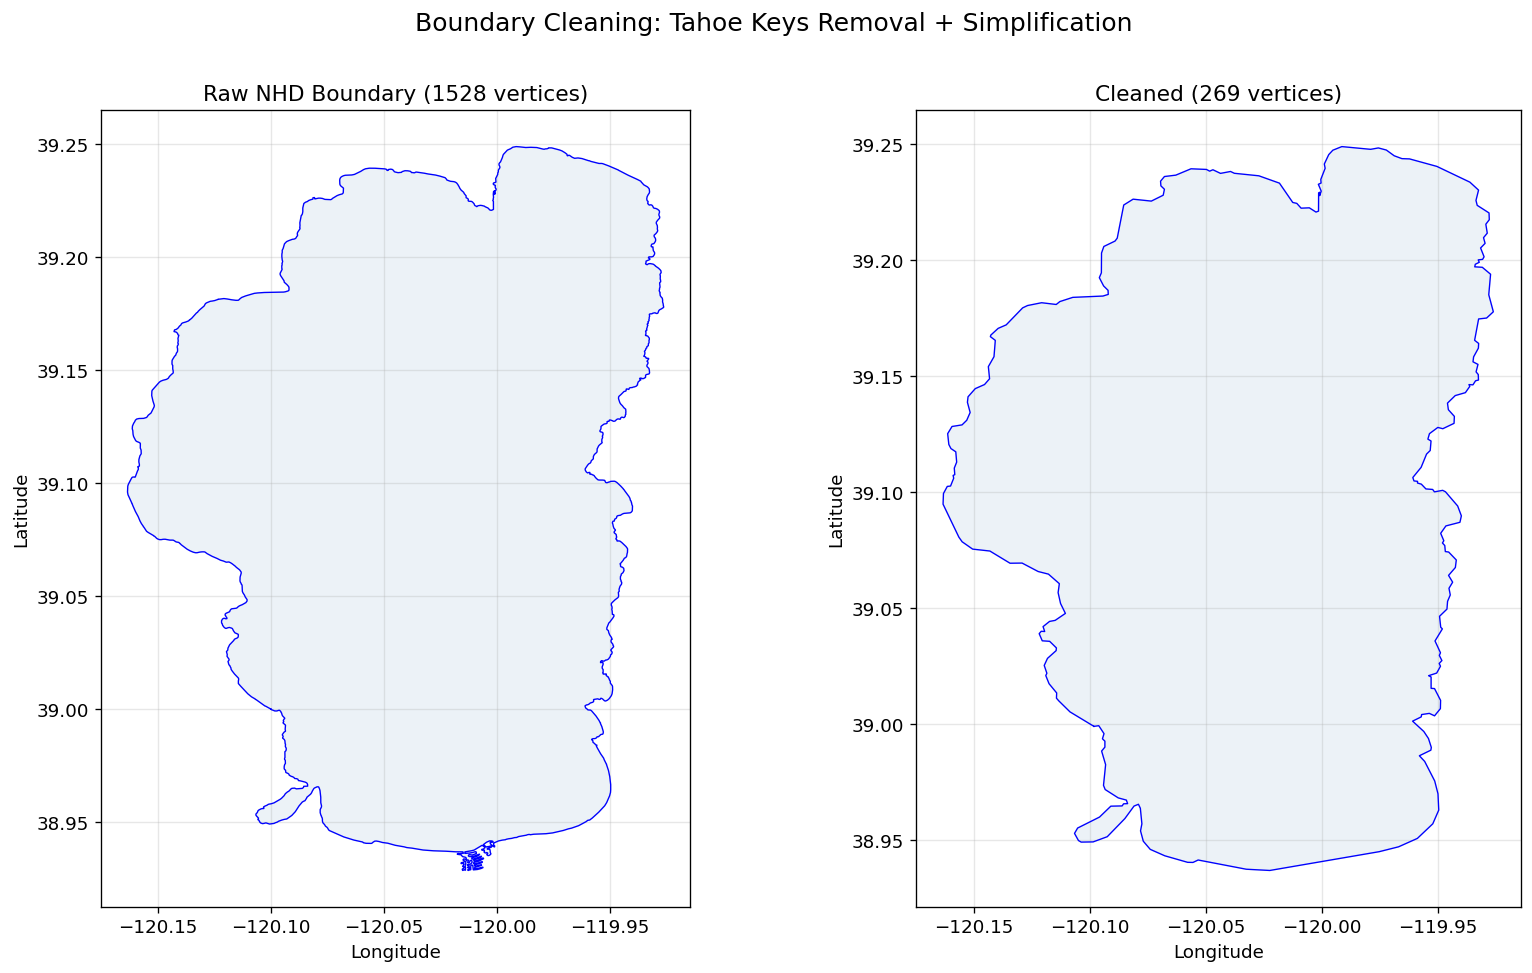


Using cleaned boundary for spline fitting and arc-length computation.


In [6]:
from shapely.geometry import Polygon as ShapelyPolygon

# --- Step 1: Remove the Tahoe Keys ---
# The Keys sit in the southern portion of the lake, roughly:
#   latitude < 38.945 and longitude > -120.02
# We remove vertices inside this box, which clips out the marina channels

keys_mask = (lat < 38.945) & (lon > -120.02)
n_keys = np.sum(keys_mask)
print(f'Tahoe Keys vertices identified: {n_keys}')

# Keep everything outside the Tahoe Keys box
lon_clipped = lon[~keys_mask]
lat_clipped = lat[~keys_mask]
print(f'Vertices after clipping: {len(lon_clipped)} (removed {n_keys})')

# --- Step 2: Simplify remaining minor detail ---
clipped_polygon = ShapelyPolygon(zip(lon_clipped, lat_clipped))
tolerance = 0.0005  # ~100 m; adjust if needed
simplified = clipped_polygon.simplify(tolerance, preserve_topology=True)

simple_coords = np.array(simplified.exterior.coords)
lon_simple = simple_coords[:, 0]
lat_simple = simple_coords[:, 1]

print(f'Vertices after simplification: {len(lon_simple)}')

# --- Before / After comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

ax = axes[0]
ax.plot(lon, lat, 'b-', linewidth=0.8)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_title(f'Raw NHD Boundary ({len(lon)} vertices)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lon_simple, lat_simple, 'b-', linewidth=0.8)
ax.fill(lon_simple, lat_simple, alpha=0.1, color='steelblue')
ax.set_title(f'Cleaned ({len(lon_simple)} vertices)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.suptitle('Boundary Cleaning: Tahoe Keys Removal + Simplification', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Replace lon/lat for all downstream cells
lon = lon_simple
lat = lat_simple
print(f'\nUsing cleaned boundary for spline fitting and arc-length computation.')

## 5. Saving Boundary Coordinates

We save the extracted boundary to a CSV file so it can be loaded independently in future notebooks without re-querying the server. This also serves as the input for the `SplineBoundary.from_file()` method.

In [7]:
# Save boundary coordinates to CSV
boundary_df = pd.DataFrame({'longitude': lon, 'latitude': lat})
boundary_df.to_csv('../data/boundaries/lake_tahoe_boundary.csv', index=False)

print(f'Saved {len(boundary_df)} boundary points to data/boundaries/lake_tahoe_boundary.csv')
print(boundary_df.head())

Saved 269 boundary points to data/boundaries/lake_tahoe_boundary.csv
    longitude   latitude
0 -120.098286  38.999146
1 -120.108601  39.005384
2 -120.113437  39.010142
3 -120.114433  39.011285
4 -120.114345  39.013550


## 6. Fitting the Spline Boundary

Our `SplineBoundary` class fits cubic splines to the boundary coordinates, creating a smooth parameterization $t \in [0, 1]$ around the lake perimeter. This is the real-world counterpart to the analytical `EllipseBoundary` used in Notebook 01.

The spline fitting process:
1. Orders boundary points sequentially around the perimeter (they already are, from the NHD polygon ring)
2. Assigns a parameter $t_i \in [0, 1]$ to each point based on its position in the sequence
3. Fits cubic splines $x(t)$ and $y(t)$ through the coordinate data
4. Computes the total arc length $L$ by numerical integration of $\sqrt{(dx/dt)^2 + (dy/dt)^2}$

In [8]:
# Fit cubic splines to the boundary coordinates
# SplineBoundary expects x_coords (longitude) and y_coords (latitude)
boundary = SplineBoundary(x_coords=lon, y_coords=lat)

# Compute total arc length (in degrees — we'll discuss units below)
L = boundary.total_arc_length()
print(f'Total arc length: {L:.4f} degrees')
print(f'Parameter range: {boundary.t_range()}')

# Verify start and end points match
start_pt = boundary.evaluate(0.0)
end_pt = boundary.evaluate(1.0)
print(f'\nStart point (t=0): ({start_pt[0]:.4f}, {start_pt[1]:.4f})')
print(f'End point (t=1):   ({end_pt[0]:.4f}, {end_pt[1]:.4f})')
print(f'Start ≈ End: {np.allclose(start_pt, end_pt, atol=1e-3)}')

Total arc length: 1.2027 degrees
Parameter range: (0.0, 1.0)

Start point (t=0): (-120.0983, 38.9991)
End point (t=1):   (-120.0983, 38.9991)
Start ≈ End: True


## 7. Verifying the Spline Fit

We overlay the spline curve on the original NHD vertices to confirm that the interpolation is faithful. A good fit means the spline passes through (or very near) each original data point without introducing spurious oscillations.

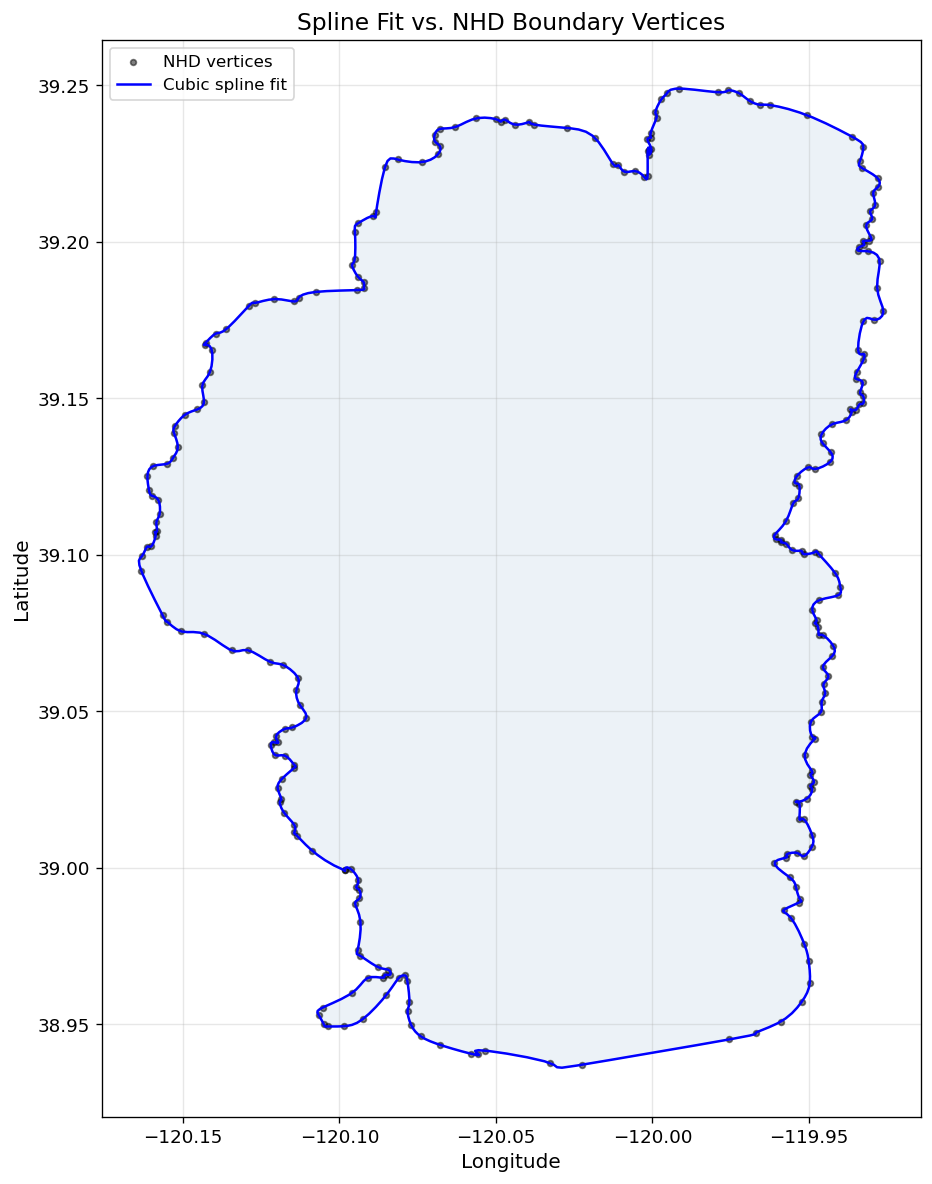

In [9]:
# Sample the spline at many points for a smooth curve
spline_pts = boundary.sample_boundary(n_points=1000)

fig, ax = plt.subplots(figsize=(8, 10))

# Original NHD vertices
ax.scatter(lon, lat, c='black', s=12, alpha=0.5, zorder=2, label='NHD vertices')

# Spline interpolation
ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'b-', linewidth=1.5,
        zorder=3, label='Cubic spline fit')

ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Spline Fit vs. NHD Boundary Vertices', fontsize=14)
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Arc-Length Parameterization

The normalized arc-length $s \in [0, 1]$ records a point's fractional position along the shoreline perimeter. We verify this by sampling $s$ at evenly spaced parameter values and checking that the mapping behaves sensibly — $s$ should increase monotonically from 0 to 1 as $t$ goes from 0 to 1.

**Note on units**: Since we're working in geographic coordinates (degrees), the arc length is in degrees rather than meters. This doesn't affect the clustering algorithm because the arc-length values are normalized to $[0, 1]$. The normalization eliminates units entirely — $s$ is a dimensionless fraction of the total perimeter.

In [10]:
# Sample arc-length values at regular t intervals
n_check = 10
t_check = np.linspace(0, 1, n_check, endpoint=False)  # exclude t=1 (same as t=0)
s_check = np.array([boundary.normalized_arc_length(t) for t in t_check])

print('Arc-length parameterization check:')
print(f'{"t":>8}  {"s":>8}  {"(lon, lat)":>24}')
print('-' * 44)
for t, s in zip(t_check, s_check):
    pt = boundary.evaluate(t)
    print(f'{t:8.3f}  {s:8.4f}  ({pt[0]:9.4f}, {pt[1]:8.4f})')

# Verify monotonicity
is_monotonic = np.all(np.diff(s_check) > 0)
print(f'\ns is monotonically increasing: {is_monotonic}')
print(f's range: [{s_check.min():.4f}, {s_check.max():.4f}]')

Arc-length parameterization check:
       t         s                (lon, lat)
--------------------------------------------
   0.000    0.0000  (-120.0983,  38.9991)
   0.100    0.0926  (-120.1332,  39.0691)
   0.200    0.1891  (-120.1437,  39.1520)
   0.300    0.3074  (-120.0678,  39.2291)
   0.400    0.3955  (-120.0003,  39.2357)
   0.500    0.4967  (-119.9323,  39.1991)
   0.600    0.5768  (-119.9426,  39.1303)
   0.700    0.6505  (-119.9470,  39.0753)
   0.800    0.7264  (-119.9524,  39.0038)
   0.900    0.9013  (-120.0777,  38.9584)

s is monotonically increasing: True
s range: [0.0000, 0.9013]


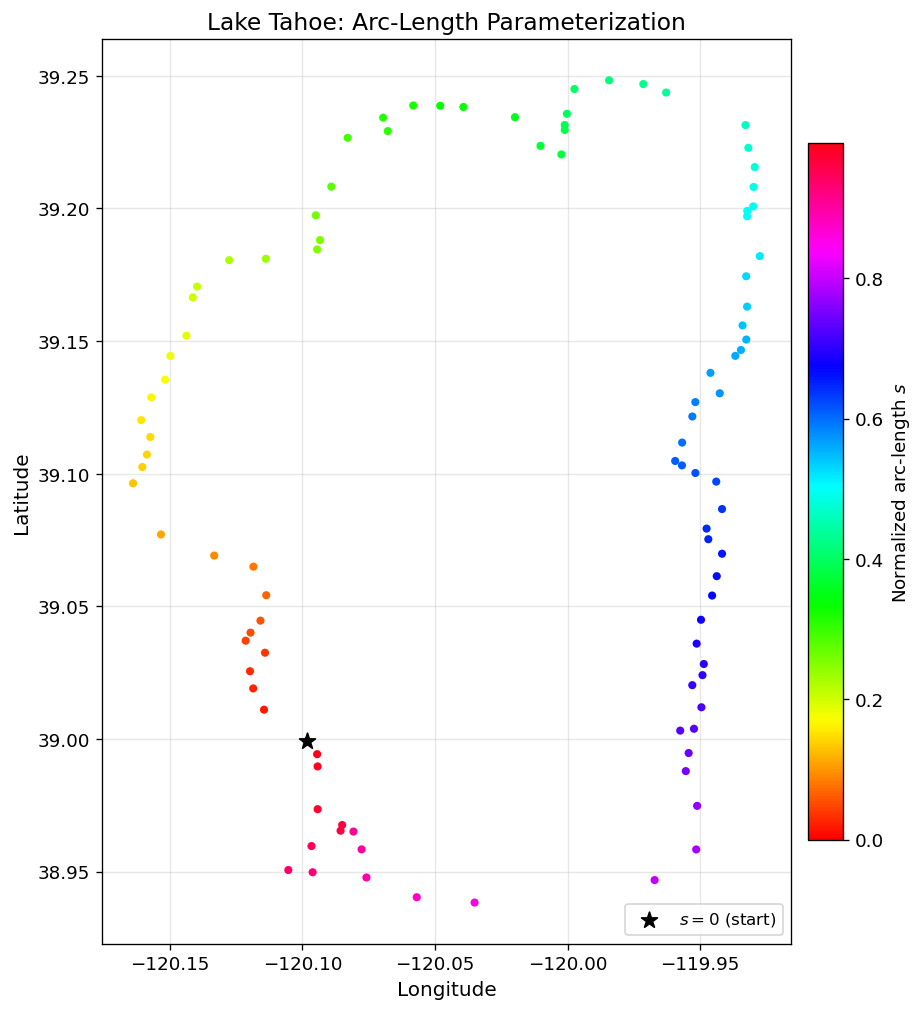

In [11]:
# Visualize the boundary colored by arc-length parameter s
n_vis = 100
t_vis = np.linspace(0, 1, n_vis, endpoint=False)
xy_vis = np.array([boundary.evaluate(t) for t in t_vis])
s_vis = np.array([boundary.normalized_arc_length(t) for t in t_vis])

fig, ax = plt.subplots(figsize=(8, 10))

scatter = ax.scatter(xy_vis[:, 0], xy_vis[:, 1], c=s_vis, cmap='hsv',
                     s=15, zorder=3)
plt.colorbar(scatter, ax=ax, label='Normalized arc-length $s$',
             shrink=0.6, aspect=20, pad=0.02)

# Mark s=0 (start)
ax.scatter(xy_vis[0, 0], xy_vis[0, 1], c='black', s=100, marker='*',
           zorder=5, label='$s = 0$ (start)')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Lake Tahoe: Arc-Length Parameterization', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Testing Point Projection

A critical operation for the clustering algorithm is projecting external points onto the boundary. Each data point (e.g., a wildfire location near the lake) gets assigned an arc-length value $s$ by finding the closest point on the boundary and computing its normalized arc-length.

We test this with several points around the lake to verify that the projection is geometrically sensible.

In [12]:
# Test points at known locations around Lake Tahoe
test_points = {
    'South Shore (Stateline)':  (-119.98, 38.96),
    'West Shore (Homewood)':    (-120.17, 39.08),
    'North Shore (Tahoe City)': (-120.14, 39.17),
    'East Shore (Sand Harbor)': (-119.93, 39.20),
    'Emerald Bay':              (-120.11, 38.95),
}

print('Point projection results:')
print(f'{"Location":<28} {"(lon, lat)":<22} {"t_proj":>8} {"s_proj":>8}')
print('-' * 72)

projected_data = []
for name, (px, py) in test_points.items():
    t_proj, s_proj = boundary.project_point(px, py)
    proj_pt = boundary.evaluate(t_proj)
    projected_data.append((name, px, py, t_proj, s_proj, proj_pt))
    print(f'{name:<28} ({px:.2f}, {py:.2f})     {t_proj:8.4f} {s_proj:8.4f}')

Point projection results:
Location                     (lon, lat)               t_proj   s_proj
------------------------------------------------------------------------
South Shore (Stateline)      (-119.98, 38.96)       0.8621   0.8047
West Shore (Homewood)        (-120.17, 39.08)       0.1171   0.1197
North Shore (Tahoe City)     (-120.14, 39.17)       0.2194   0.2074
East Shore (Sand Harbor)     (-119.93, 39.20)       0.4911   0.4936
Emerald Bay                  (-120.11, 38.95)       0.9318   0.9373


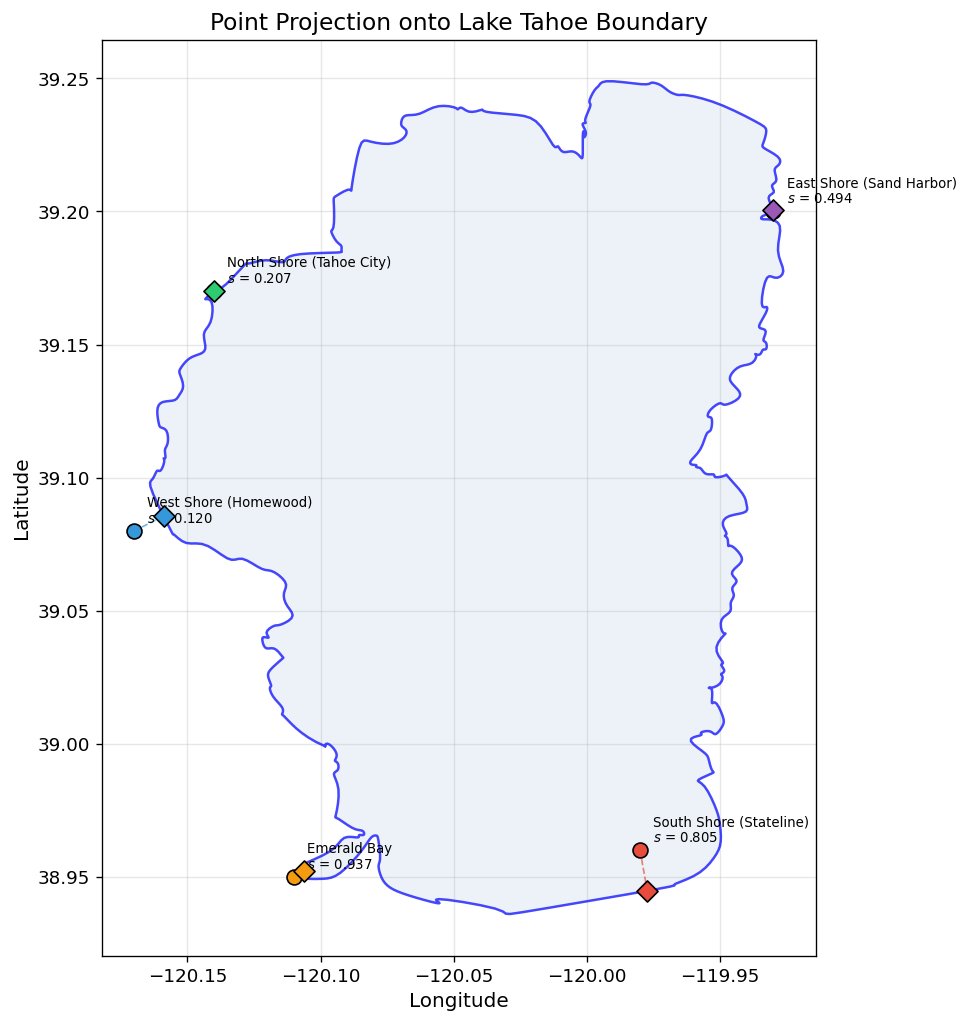

In [13]:
fig, ax = plt.subplots(figsize=(8, 10))

# Draw boundary
ax.plot(spline_pts[:, 0], spline_pts[:, 1], 'b-', linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

# Plot test points and their projections
colors_proj = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']
for i, (name, px, py, t_proj, s_proj, proj_pt) in enumerate(projected_data):
    # Original point
    ax.scatter(px, py, c=colors_proj[i], s=80, edgecolors='black',
               linewidth=1, zorder=5)
    # Projected point on boundary
    ax.scatter(proj_pt[0], proj_pt[1], c=colors_proj[i], s=80, marker='D',
               edgecolors='black', linewidth=1, zorder=5)
    # Line connecting them
    ax.plot([px, proj_pt[0]], [py, proj_pt[1]], '--', color=colors_proj[i],
            linewidth=1, alpha=0.7)
    # Label
    ax.annotate(f'{name}\n$s$ = {s_proj:.3f}', (px, py),
                textcoords='offset points', xytext=(8, 5), fontsize=8)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Point Projection onto Lake Tahoe Boundary', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Testing Centroid Projection

The centroid update step in our k-Means algorithm averages cluster members' positions *on the boundary* and projects the average back. We verify this works by computing the centroid of a few test points.

In [14]:
# Compute boundary-aware centroid for the north+east test points
north_east_t = [projected_data[2][3], projected_data[3][3]]  # Tahoe City, Sand Harbor
t_centroid, s_centroid = boundary.project_centroid(north_east_t)
centroid_pt = boundary.evaluate(t_centroid)

print('Centroid projection test:')
print(f'  Input points: {projected_data[2][0]} (s={projected_data[2][4]:.3f}), '
      f'{projected_data[3][0]} (s={projected_data[3][4]:.3f})')
print(f'  Centroid: t={t_centroid:.4f}, s={s_centroid:.4f}')
print(f'  Centroid location: ({centroid_pt[0]:.4f}, {centroid_pt[1]:.4f})')
print(f'  (Should be on the north shore, between Tahoe City and Sand Harbor)')

Centroid projection test:
  Input points: North Shore (Tahoe City) (s=0.207), East Shore (Sand Harbor) (s=0.494)
  Centroid: t=0.3553, s=0.3670
  Centroid location: (-120.0120, 39.2242)
  (Should be on the north shore, between Tahoe City and Sand Harbor)


## 11. Summary

This notebook accomplished the following:

1. **Data acquisition**: Queried the USGS National Hydrography Dataset directly via its public REST endpoint to extract Lake Tahoe's polygon boundary — the authoritative federal data source for U.S. surface water features.

2. **Spline parameterization**: Fitted cubic splines to the boundary coordinates using our `SplineBoundary` class, creating a smooth $t \in [0, 1]$ parameterization of the shoreline.

3. **Arc-length normalization**: Verified that the normalized arc-length $s \in [0, 1]$ increases monotonically around the lake, providing a well-behaved position coordinate for clustering.

4. **Projection operations**: Tested point projection and centroid projection — the two operations that the clustering algorithm relies on for assigning data points to boundary positions and updating cluster centroids.

5. **Data export**: Saved the boundary coordinates to CSV for use in subsequent notebooks without requiring a network connection.

### Transition to the Real-World Application

The `SplineBoundary` object created here serves the same role as the `EllipseBoundary` in Notebook 01 — it defines the obstacle geometry and provides the arc-length infrastructure. In Notebook 03, we will:

- Load wildfire occurrence data from the FPA FOD database
- Project each fire's location onto this Lake Tahoe boundary to compute its $s$ value
- Run the full obstacle-aware k-Means with geographic, arc-length, *and* attribute features
- Optimize the weights $(\alpha, \beta, \gamma)$ via simulated annealing

### Key File Produced

| File | Description |
|------|-------------|
| `data/boundaries/lake_tahoe_boundary.csv` | Lake Tahoe shoreline coordinates (lon, lat) from NHD |